# Task 5: Personal Loan Acceptance Prediction 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('bank.csv')

# For demonstration, I'll create a sample structure
print("Dataset Structure:")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

Dataset Structure:
Shape: (11162, 17)

First few rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None

Missing Values:
age          0
job          0
marital      0
education    0
def

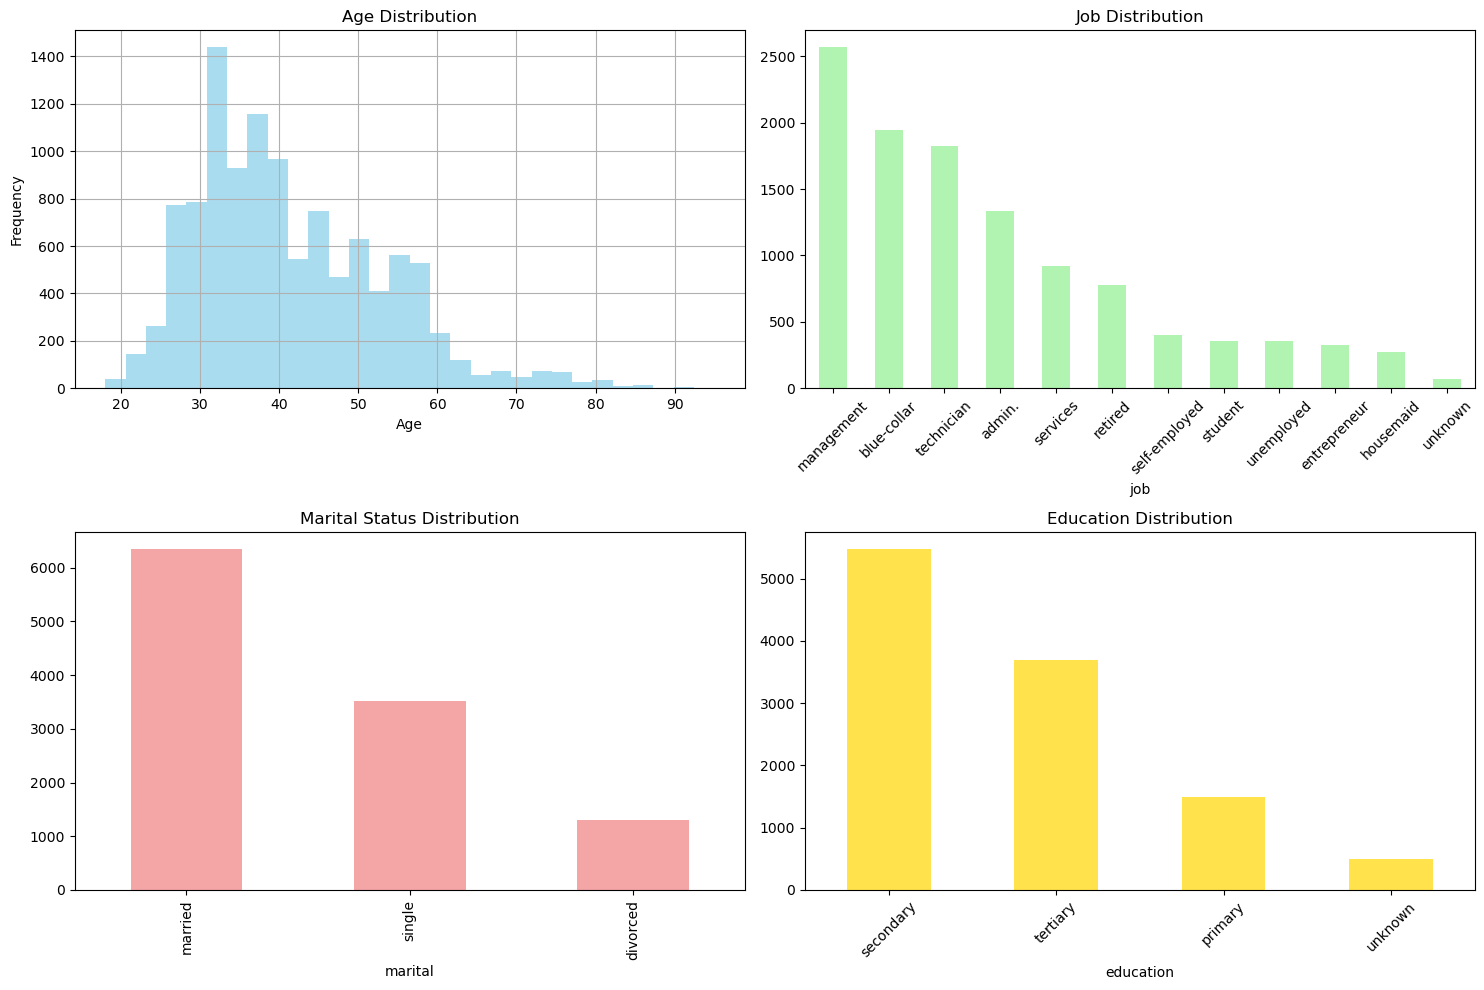

In [2]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Key demographic features exploration
demographic_features = ['age', 'job', 'marital', 'education']

# Age distribution
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
df['age'].hist(bins=30, alpha=0.7, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Job distribution
plt.subplot(2, 2, 2)
df['job'].value_counts().plot(kind='bar', alpha=0.7, color='lightgreen')
plt.title('Job Distribution')
plt.xticks(rotation=45)

# Marital status distribution
plt.subplot(2, 2, 3)
df['marital'].value_counts().plot(kind='bar', alpha=0.7, color='lightcoral')
plt.title('Marital Status Distribution')

# Education distribution
plt.subplot(2, 2, 4)
df['education'].value_counts().plot(kind='bar', alpha=0.7, color='gold')
plt.title('Education Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

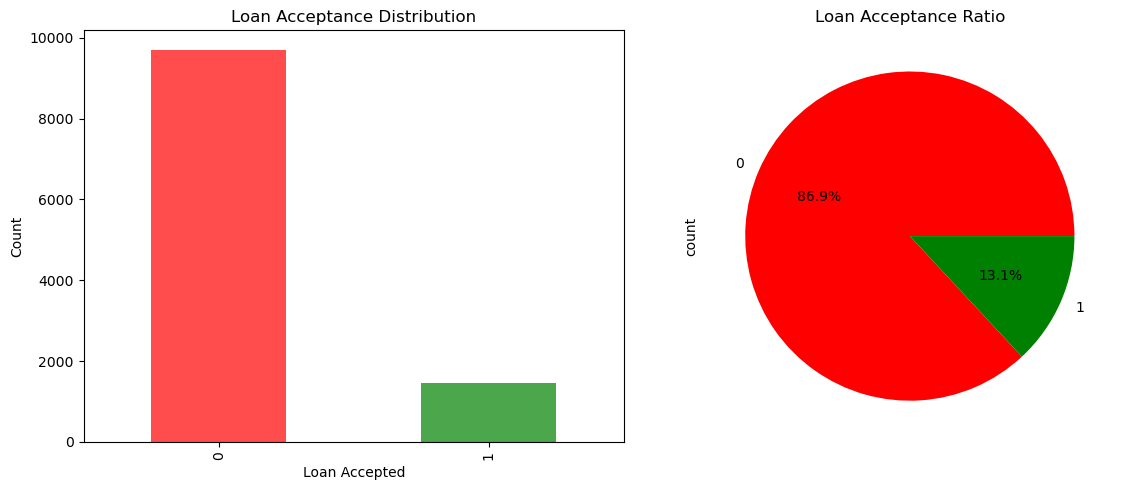

In [14]:
# Assuming the target variable is 'loan' or similar
# Let's check the distribution of loan acceptance
target_variable = 'loan'  # Adjust based on actual column name

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[target_variable].value_counts().plot(kind='bar', color=['red', 'green'], alpha=0.7)
plt.title('Loan Acceptance Distribution')
plt.xlabel('Loan Accepted')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df[target_variable].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Loan Acceptance Ratio')

plt.tight_layout()
plt.show()

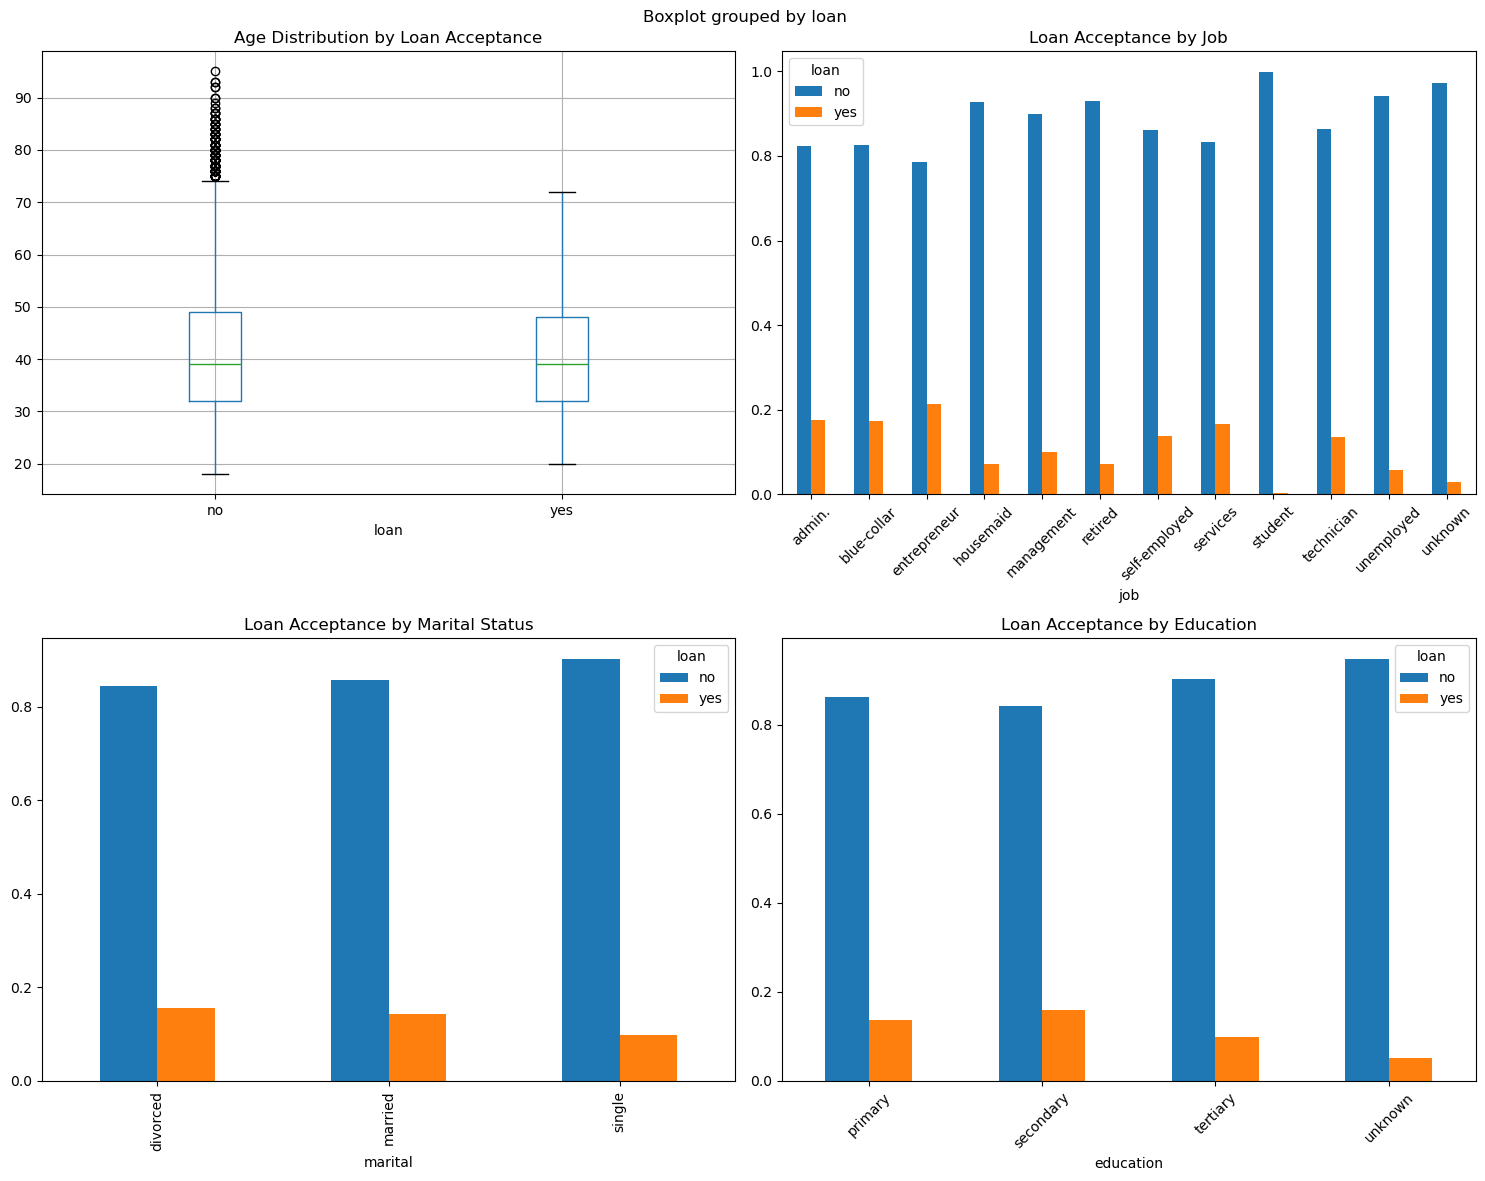

In [4]:
# Analyze how different features relate to loan acceptance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Age vs Loan Acceptance
df.boxplot(column='age', by=target_variable, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Loan Acceptance')

# Job vs Loan Acceptance
job_loan = pd.crosstab(df['job'], df[target_variable], normalize='index')
job_loan.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Loan Acceptance by Job')
axes[0,1].tick_params(axis='x', rotation=45)

# Marital Status vs Loan Acceptance
marital_loan = pd.crosstab(df['marital'], df[target_variable], normalize='index')
marital_loan.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Loan Acceptance by Marital Status')

# Education vs Loan Acceptance
education_loan = pd.crosstab(df['education'], df[target_variable], normalize='index')
education_loan.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Loan Acceptance by Education')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Create a copy for modeling
df_model = df.copy()

# Handle categorical variables
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'contact', 'month', 'poutcome']
label_encoders = {}

for col in categorical_columns:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le

# Prepare features and target
X = df_model.drop(columns=[target_variable])
y = df_model[target_variable]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (7813, 16)
Test set size: (3349, 16)


=== Logistic Regression Results ===
Accuracy: 0.8695

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      2911
           1       1.00      0.00      0.00       438

    accuracy                           0.87      3349
   macro avg       0.93      0.50      0.47      3349
weighted avg       0.89      0.87      0.81      3349



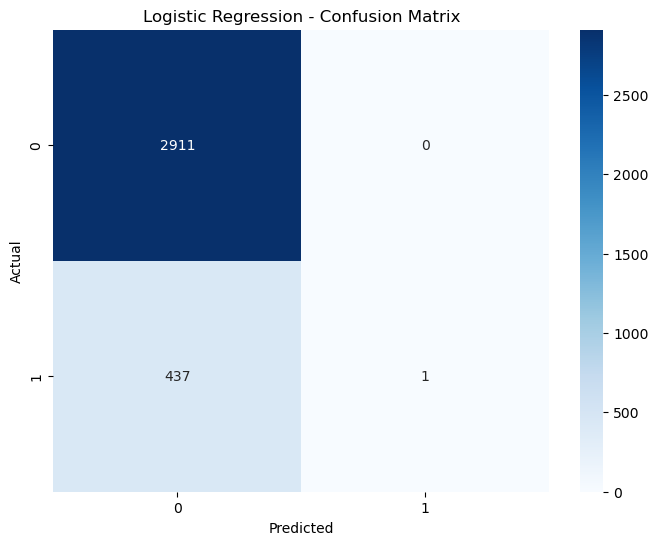

In [7]:
# Fix: Convert categorical columns to numerical using Label Encoding
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_columns = X_train.select_dtypes(include=['object']).columns

# Convert categorical variables to numerical
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# Also encode target if it's categorical
if y_train.dtype == 'object':
    le_target = LabelEncoder()
    y_train = le_target.fit_transform(y_train)
    y_test = le_target.transform(y_test)

# Now train the model - this should work
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

# Continue with your original code...
y_pred_logreg = logreg.predict(X_test)
y_pred_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Logistic Regression Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== Decision Tree Results ===
Accuracy: 0.8647

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      2911
           1       0.27      0.02      0.04       438

    accuracy                           0.86      3349
   macro avg       0.57      0.51      0.48      3349
weighted avg       0.79      0.86      0.81      3349



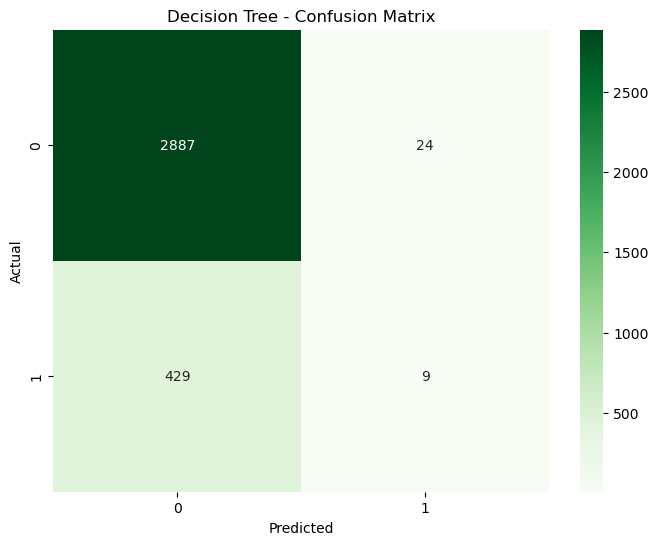

In [8]:
# Decision Tree Model
dtree = DecisionTreeClassifier(random_state=42, max_depth=5)
dtree.fit(X_train, y_train)

# Predictions
y_pred_dtree = dtree.predict(X_test)

# Evaluation
print("=== Decision Tree Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dtree):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dtree))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_dtree = confusion_matrix(y_test, y_pred_dtree)
sns.heatmap(cm_dtree, annot=True, fmt='d', cmap='Greens')
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

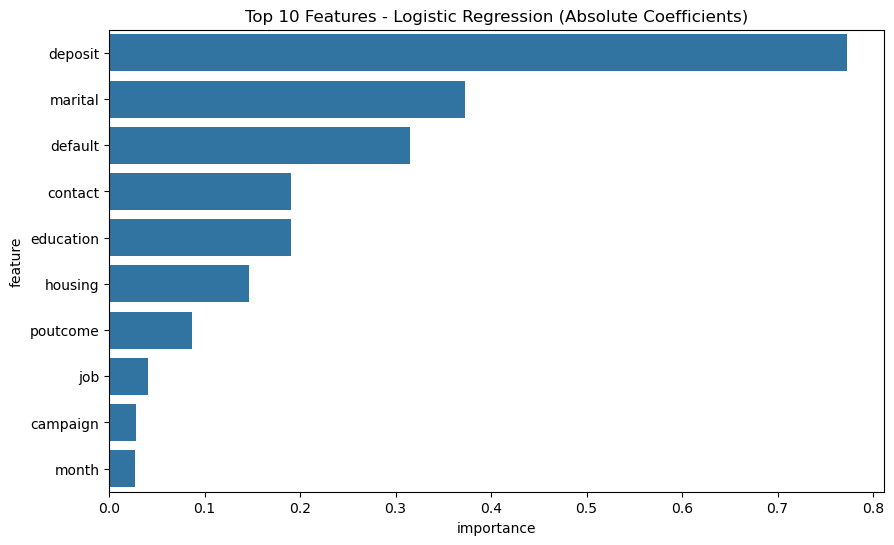

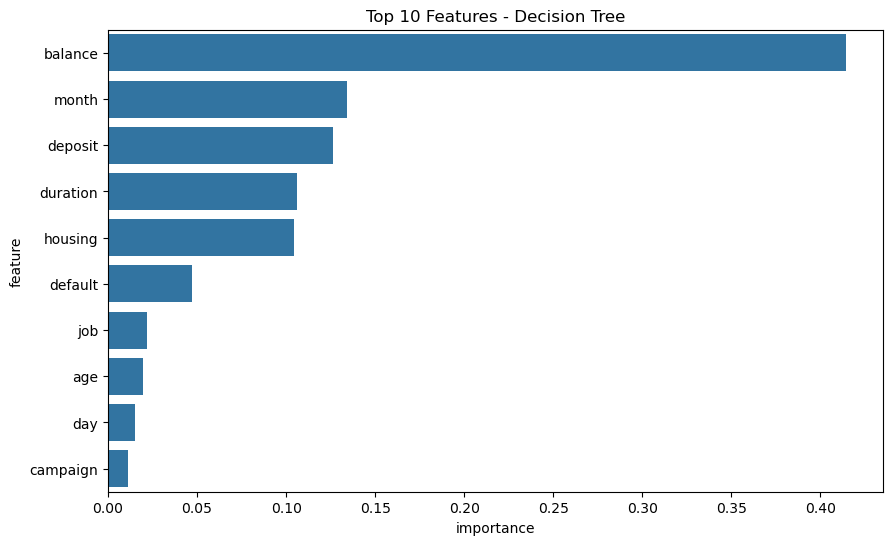

In [9]:
# Feature Importance from Logistic Regression
feature_importance_logreg = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(logreg.coef_[0])
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_logreg.head(10), x='importance', y='feature')
plt.title('Top 10 Features - Logistic Regression (Absolute Coefficients)')
plt.show()

# Feature Importance from Decision Tree
feature_importance_dtree = pd.DataFrame({
    'feature': X.columns,
    'importance': dtree.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_dtree.head(10), x='importance', y='feature')
plt.title('Top 10 Features - Decision Tree')
plt.show()

In [11]:
# Convert target variable to numerical (if it's not already)
df[target_variable] = df[target_variable].map({'yes': 1, 'no': 0})

# Now run your analysis code
print("=== BUSINESS INSIGHTS ===")

# 1. Age-based analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], 
                         labels=['Young', 'Middle-aged', 'Senior', 'Elderly'])
age_acceptance = df.groupby('age_group')[target_variable].mean().sort_values(ascending=False)

print("\n1. Loan Acceptance by Age Group:")
for age_group, rate in age_acceptance.items():
    print(f"   {age_group}: {rate:.2%}")

# 2. Job-based analysis
job_acceptance = df.groupby('job')[target_variable].mean().sort_values(ascending=False)
print("\n2. Top 5 Jobs by Loan Acceptance:")
for job, rate in job_acceptance.head().items():
    print(f"   {job}: {rate:.2%}")

# 3. Education-based analysis
education_acceptance = df.groupby('education')[target_variable].mean().sort_values(ascending=False)
print("\n3. Education Level and Loan Acceptance:")
for education, rate in education_acceptance.items():
    print(f"   {education}: {rate:.2%}")

# 4. Marital status analysis
marital_acceptance = df.groupby('marital')[target_variable].mean()
print("\n4. Marital Status and Loan Acceptance:")
for status, rate in marital_acceptance.items():
    print(f"   {status}: {rate:.2%}")

=== BUSINESS INSIGHTS ===

1. Loan Acceptance by Age Group:
   Senior: 14.92%
   Middle-aged: 13.60%
   Young: 12.41%
   Elderly: 1.47%

2. Top 5 Jobs by Loan Acceptance:
   entrepreneur: 21.34%
   admin.: 17.69%
   blue-collar: 17.34%
   services: 16.68%
   self-employed: 13.83%

3. Education Level and Loan Acceptance:
   secondary: 15.81%
   primary: 13.67%
   tertiary: 9.84%
   unknown: 5.23%

4. Marital Status and Loan Acceptance:
   divorced: 15.55%
   married: 14.38%
   single: 9.84%


In [12]:
# Create customer segments with high acceptance probability
print("\n=== RECOMMENDED CUSTOMER SEGMENTS ===")

# Identify high-potential segments
high_potential_segments = []

# Segment 1: Based on job and education
segment1 = df[(df['job'].isin(job_acceptance.head(3).index)) & 
              (df['education'].isin(education_acceptance.head(2).index))]
if len(segment1) > 0:
    segment1_rate = segment1[target_variable].mean()
    high_potential_segments.append(('High-educated professionals', segment1_rate))

# Segment 2: Based on age and marital status
segment2 = df[(df['age_group'] == 'Middle-aged') & 
              (df['marital'] == 'married')]
if len(segment2) > 0:
    segment2_rate = segment2[target_variable].mean()
    high_potential_segments.append(('Middle-aged married', segment2_rate))

# Display recommendations
for segment_name, acceptance_rate in sorted(high_potential_segments, key=lambda x: x[1], reverse=True):
    print(f"✓ {segment_name}: {acceptance_rate:.2%} acceptance rate")

# Final model comparison
print(f"\n=== MODEL COMPARISON ===")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dtree):.4f}")

# Recommendation
best_model = "Logistic Regression" if accuracy_score(y_test, y_pred_logreg) > accuracy_score(y_test, y_pred_dtree) else "Decision Tree"
print(f"\nRecommended Model: {best_model}")


=== RECOMMENDED CUSTOMER SEGMENTS ===
✓ High-educated professionals: 18.63% acceptance rate
✓ Middle-aged married: 15.20% acceptance rate

=== MODEL COMPARISON ===
Logistic Regression Accuracy: 0.8695
Decision Tree Accuracy: 0.8647

Recommended Model: Logistic Regression
